In [1]:
%run util.py

python version 3.12.3


['/home/afreiburger/repos/cobrakbase',
 '/home/afreiburger/repos/KBBaseModules',
 '/home/afreiburger/repos/chenry_utility_module/lib',
 '/home/afreiburger/repos/cb_annotation_ontology_api/lib',
 '/home/afreiburger/repos/KB-ModelSEEDReconstruction/lib',
 '/home/afreiburger/repos/MergeMetabolicAnnotations/lib',
 '/home/afreiburger/repos/codiffusion_bioreactor',
 '/usr/lib/python312.zip',
 '/usr/lib/python3.12',
 '/usr/lib/python3.12/lib-dynload',
 '',
 '/home/afreiburger/repos/.venv/lib/python3.12/site-packages',
 '/home/afreiburger/repos']

KBBaseModules 0.0.1
modelseedpy 0.3.3
cobrakbase 0.3.1
Output files printed to:/home/afreiburger/repos/codiffusion_bioreactor/Sludge/nboutput when using KBDevUtils.output_dir


# Load BV-BRC data

## download all 16S genes from BV-BRC

### metadata

In [1]:
from json import dump, load
import requests

batch_size = 25000
count = 0
start = batch_size * count
call = f'https://www.bv-brc.org/api/genome_feature/?and(eq(annotation,PATRIC),eq(feature_type,"rRNA"),eq(product,"16S"))&limit({batch_size},{start})' #&http_accept=application/dna+fasta"
request = requests.get(call)
data = request.json()
metadata_16S = {} #load(open("datacache/16S_metadata.json", "r"))
while data:
    count += 1
    for gene in data:
        genomeID = gene.pop("patric_id").replace("fig|", '')
        metadata_16S.setdefault(genomeID, gene)
    if count % 5 == 0:
        dump(metadata_16S, open(f"16S_metadata{count}.json", "w"))
        metadata_16S = {}

    start += batch_size
    call = f'https://www.bv-brc.org/api/genome_feature/?and(eq(annotation,PATRIC),eq(feature_type,"rRNA"),eq(product,"16S"))&limit({batch_size},{start})' #&http_accept=application/dna+fasta"
    request = requests.get(call)
    data = request.json()
    print(count)

dump(metadata_16S, open(f"16S_metadata{count}.json", "w"))
metadata_16S = {}


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47


In [3]:
from json import load, dump
from glob import glob
import os
mainMD = {}
for md in glob("16S_metadata*.json"):
    MD = load(open(md, 'r'))
    mainMD.update(MD)
    os.remove(md)

dump(mainMD, open("model_inputs/16S_metadata.json", "w"))

#### processing taxonomy for acquired genomes

In [156]:
mainMD = load(open("model_inputs/16S_metadata.json", "r"))
items = list(mainMD.items())

In [157]:
items[:2]

[('2364649.4.rna.62',
  {'accession': 'BMQU01000052',
   'annotation': 'PATRIC',
   'date_inserted': '2020-11-28T16:45:30.590Z',
   'date_modified': '2020-11-28T16:45:30.590Z',
   'end': 5013,
   'feature_id': 'PATRIC.2364649.4.BMQU01000052.rRNA.3472.5013.rev',
   'feature_type': 'rRNA',
   'genome_id': '2364649.4',
   'genome_name': 'Pseudomonas laurentiana strain JCM 32154',
   'location': 'complement(3472..5013)',
   'na_length': 1542,
   'na_sequence_md5': '3aa91ee3decd52a4ec32e06cd80d5ac9',
   'owner': 'PATRIC@patricbrc.org',
   'product': 'SSU rRNA ## 16S rRNA, small subunit ribosomal RNA',
   'public': True,
   'refseq_locus_tag': 'GCM10009504_r00040',
   'sequence_id': '2364649.4.con.0052',
   'start': 3472,
   'strand': '-',
   'taxon_id': 2364649,
   'segments': ['3472..5013'],
   '_version_': 1809033108441268200}),
 ('485.6304.rna.51',
  {'accession': '485.6304.con.0053',
   'annotation': 'PATRIC',
   'date_inserted': '2020-02-04T09:53:47.854Z',
   'date_modified': '2020-02-

In [ ]:
for geneID, contents in mainMD.items():
    

### sequences

In [4]:
from json import dump, load
import requests

batch_size = 25000
count = 0
start = batch_size * count
call = f'https://www.bv-brc.org/api/genome_feature/?and(eq(annotation,PATRIC),eq(feature_type,"rRNA"),eq(product,"16S"))&limit({batch_size},{start})&http_accept=application/dna+fasta'
request = requests.get(call)
Fasta16S = {} #load(open("Fasta16S.json", "r"))
data = request.text.strip() #.json()
while data:
    count += 1
    lines = data.split("\n")
    for line in lines:
        if line.startswith(">"):
            genomeID = line[1:]
            Fasta16S.setdefault(genomeID, "")
        else:
            Fasta16S[genomeID] += line
    if count % 5 == 0:
        dump(Fasta16S, open(f"Fasta16S{count}.json", "w"))
        Fasta16S = {}

    start += batch_size
    call = f'https://www.bv-brc.org/api/genome_feature/?and(eq(annotation,PATRIC),eq(feature_type,"rRNA"),eq(product,"16S"))&limit({batch_size},{start})&http_accept=application/dna+fasta'
    request = requests.get(call)
    data = request.text.strip() #.json()
    # display(metadata_16S)
    # break
    print(count)

dump(Fasta16S, open(f"Fasta16S{count}.json", "w"))
Fasta16S = {}

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47


In [5]:
from json import load, dump
from glob import glob
import os
mainFasta = {}
for fasta in glob("Fasta*.json"):
    fa = load(open(fasta, 'r'))
    mainFasta.update(fa)
    os.remove(fasta)

dump(mainFasta, open("model_inputs/BV_BRC_16S.json", "w"))

In [4]:
from json import dump
import hashlib

new_md5_seq, md5_ID = {}, {}
for ID, seq in mainFasta.items():
    md5 = hashlib.md5(seq.encode('utf-8')).hexdigest()
    new_md5_seq[md5] = seq
    md5_ID[md5] = ID
dump(new_md5_seq, open("model_inputs/16S_md5_seq.json", 'w'), indent=2)
dump(md5_ID, open("model_inputs/16S_md5_ID.json", 'w'), indent=2)

In [7]:
from numpy import mean, std
from json import load, dump

md5_seq = load(open("model_inputs/16S_md5_seq.json", 'r'))
lengths = [len(x) for x in md5_seq.values() if x is not None]
print("eAmplicon lengths", int(mean(lengths)), "+/-", int(std(lengths)), "; range", min(lengths), "-", max(lengths))
print(len(lengths))

eAmplicon lengths 1142 +/- 489 ; range 0 - 5998
368556


## load predownloaded 16S genes

In [2]:
from json import load
mainFasta = load(open("model_inputs/BV_BRC_16S.json", "r"))
mainMD = load(open("model_inputs/16S_metadata.json", "r"))
md5_seq = load(open("model_inputs/16S_md5_seq.json", 'r'))

# gene_ids = {}
# with open('data/16s_RNA_PATRIC.frn', 'r') as file:
#     content = file.read()
# lines = content.split('\n')
# for line in lines:
#     if line.startswith('>'):
#         array = line.split(' ')
#         gene_id = array[0][1:]
#         gene_ids[gene_id] = None

# util.save("16s_geneIDs", gene_ids)

FileNotFoundError: [Errno 2] No such file or directory: 'model_inputs/16S_metadata.json'

## compare geneIDs

In [2]:
metaData_IDs = list(mainMD.keys())
fasta_IDs = list([x.split("|")[1] for x in mainFasta.keys()])
# print("metaData_IDs", len(metaData_IDs), metaData_IDs[:4])
# print("fasta_IDs", len(fasta_IDs), fasta_IDs[:4])
print(set(metaData_IDs).symmetric_difference(set(fasta_IDs)))

set()


## cutting 16S genes at the experimental primer locations

In [1]:
from Bio import SeqUtils, SeqIO, Align, pairwise2
from numpy import mean, std
from Bio.Seq import Seq
from json import load, dump
import os

amplicon_lengths = []
excessive_amplicons = []
insufficient_amplicons = []
ambiguous_basepairs = []
ambiguous_sequences = {}
def segment_16S(f_primer,r_primer,gene):
    # Find exact sequence matches with the F and then R primers.
    fwd_ePCR = SeqUtils.nt_search(str(gene),f_primer)
    rev_ePCR = SeqUtils.nt_search(str(gene),r_primer.reverse_complement())
    # If both primers match:
    if len(fwd_ePCR) < 2 or len(rev_ePCR) < 2:  return None

    # print(f"Forward primer match: {fwd_ePCR}")
    # print(f"Reverse primer match: {rev_ePCR}")
    # Add primer length to find start of amplicon sequence from forward match.
    start_cut = fwd_ePCR[1]+len(f_primer)
    # The beginning of the reverse primer match is the end of the amplicon.
    end_cut = rev_ePCR[1]
    # Use the start and end positions to get the eAmplicon sequence.
    eAmplicon = gene[start_cut:end_cut]
    ambiguous = str(eAmplicon).upper().count("N")
    if str(eAmplicon).upper().count("NN") > 0:
        ambiguous_sequences[gene] = ambiguous
        ambiguous_basepairs.append(ambiguous)
        return None
    eAmplicon_length = len(eAmplicon)
    if ambiguous > int(0.005*eAmplicon_length):   # floor behavior, effectively setting the limit of 0.5%
        ambiguous_sequences[gene] = ambiguous
        ambiguous_basepairs.append(ambiguous)
        return None
    
    ## filtering amplicons if their length seems unreasonable (beyond the 200-500bp range)
    if eAmplicon_length > 500:  excessive_amplicons.append(eAmplicon_length) ; return None
    elif eAmplicon_length < 200:  insufficient_amplicons.append(eAmplicon_length) ; return None
    amplicon_lengths.append(eAmplicon_length)
    # print(f"eAmplicon length: {eAmplicon_length}")
    # print(f"eAmplicon sequence: {eAmplicon} \n")
    
    return eAmplicon


# cut the database sequence according to the experimental primers
# forward_primer = Seq("GTGYCAGCMGCCGCGGTAA")
# reverse_primer = Seq("CCGYCAATTYMTTTRAGTTT")
forward_primer = Seq("MGCCGCGGTAA")
reverse_primer = Seq("TYMTTTRAGTTT")

Y = ["C", "T"]
M = ["A", "C"]
R = ["A", "G"]

md5_cutSeq = {}
failures = []
for md5, seq in md5_seq.items():
    if seq is None:  failures.append(md5) ; continue
    segment = segment_16S(forward_primer,reverse_primer,seq.upper())
    if segment is None:  failures.append(md5) ; continue
    md5_cutSeq[segment] = md5

dump(md5_cutSeq, open("modeling_files/16S_md5_cutSeq.json", 'w'))

print("failures,", len(failures))
print("amplicon length", mean(amplicon_lengths), "+/-", std(amplicon_lengths), "; range", min(amplicon_lengths), "-", max(amplicon_lengths))
print("excessive amplicons (>500bp):", len(excessive_amplicons), excessive_amplicons)
print("insufficient amplicons (<200bp):", len(insufficient_amplicons), insufficient_amplicons)
print("ambiguous basepairs:", mean(ambiguous_basepairs), "+/-", std(ambiguous_basepairs), "; range", min(ambiguous_basepairs), "-", max(ambiguous_basepairs))
# print("ambiguous sequences", ambiguous_sequences)

/home/freiburger/Documents/py_venv/lib/python3.12/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


NameError: name 'md5_seq' is not defined

# mapping ASVs to BV-BRC

## Compute the alignment of the ASVs to the BV-BRC sequences

In [43]:
from Bio import SeqUtils, SeqIO, Align, pairwise2
for x in SeqIO.parse("model_inputs/dna-sequences.fasta", "fasta"):
    print(x.id)
    break

0fec351445f84bd482075ceda6123f46


In [13]:
# %%time
# TODO:  test these match/mismatch scoring against either synthetic data from PATRIC or from a case study
from pandas import DataFrame
from json import load, dump

alignments_output_dir = "alignments/"
md5_cutSeq = load(open("modeling_files/16S_md5_cutSeq.json", 'r'))
abundances_df = DataFrame(load(open("model_inputs/abundances.json", 'r')))
# display(abundances_df)

aligner = Align.PairwiseAligner(
    mode='global', match_score=1, mismatch_score=0,
    open_gap_score = -1, extend_gap_score = -0.5
    )
def alignments(amplicon):
    print(f"{amplicon.id} is being processed.")
    output = {amplicon.id: {eAmplicon: aligner.score(amplicon, eAmplicon)/len(eAmplicon)
                            for eAmplicon in md5_cutSeq.keys()}}
    dump(output, open(f"{alignments_output_dir}/{amplicon.id}.json", "w"), indent=3)
    return output


fasta_path = "model_inputs/dna-sequences.fasta"
parallelize = True
args = [x for x in SeqIO.parse(fasta_path, "fasta")
        if (f"{x.id}.json" not in os.listdir(alignments_output_dir)
           and x.id in abundances_df.index)]#[:100]
if args == []: raise IndexError("No alignments need to be computed")
if not parallelize:
    outputs = []
    for arg in args:
        outputs.append(alignments(arg))
else:
    from multiprocess import Pool
    from os import cpu_count
    
    cpus = int(cpu_count()/8)
    print(f"{cpus} cores are being used.  The first argument is {args[0]}")
    pool = Pool(cpus)
    outputs = pool.map(alignments, args)


from pandas import DataFrame

combined_outputs = {}
for output in outputs:
    combined_outputs.update(output)
alignments_df = DataFrame(combined_outputs).T
alignments_df.index.name = "amplicon"
alignments_df.to_csv(alignments_output_dir + "/alignment_scores.csv", index=True)

42 cores are being used.  The first argument is ID: 0fec351445f84bd482075ceda6123f46
Name: 0fec351445f84bd482075ceda6123f46
Description: 0fec351445f84bd482075ceda6123f46
Number of features: 0
Seq('CACCGGCAGCTCAAGTGGTGGCCATTTTTATTGGGCCTAAAGCGTTCGTAGCCG...CTG')
0fec351445f84bd482075ceda6123f46 is being processed.e9e060e5e0e46911cad92b8292aeefd7 is being processed.09ee5eb3e6c726c7c8242f6e97453fc2 is being processed.
07e00e1bcc9d9a3c50591f721785e591 is being processed.dc9b83b9dbf521d0d0b0e1576e44d06a is being processed.
52708c2cfa926ba9b2f69878c97cee2c is being processed.

6075255b58efbd350ad34112f80f970a is being processed.5040d210b906c738569bf1c3505ad558 is being processed.

e79a45f432d0ccc86adbf9bbe7cef2a7 is being processed.
b64f2cd0b47a6548ebe2077c728b213f is being processed.8c86a02bd0f2c7a90bb40b735577a623 is being processed.

3fb688a9024c5d9e0c97cf7a6859063a is being processed.
4e4ca97fadb8b8e92470ccce2ff91460 is being processed.
d693c275c376753e40770f95ba69a9f9 is being processed.


In [14]:
from numpy import mean, std
lengths = [len(x.seq) for x in args]
print("amplicon lengths", int(mean(lengths)), "+/-", int(std(lengths)), "; range", min(lengths), "-", max(lengths))
print(len(lengths))

amplicon lengths 373 +/- 4 ; range 339 - 408
2857


### aggregate the alignments into a single file

In [ ]:
# from pandas import DataFrame
# from json import load
# from glob import glob
# combined_outputs = {}
# # for d in outputs:
# for alignment in glob(f"{alignments_output_dir}/*.json"):
#     d = load(open(alignment, 'r'))
#     combined_outputs.update(d)
# alignments_df = DataFrame(combined_outputs).T
# alignments_df.index.name = "amplicon"
# alignments_df.to_csv(alignments_output_dir + "/alignment_scores.csv", index=True)

## determining the best matches

In [15]:
from pandas import read_csv

best_matches = {} #util.load("best_matches")
for amplicon, row in alignments_df.iterrows():
    best_matches[amplicon] = {}
    matches = {k: round(v,2) for k,v in row.to_dict().items() if v > 0.8}
    for gene_seq, score in matches.items():
        best_matches[amplicon][score] = best_matches[amplicon].setdefault(score, [])
        best_matches[amplicon][score].append(md5_cutSeq[gene_seq])
    best_matches[amplicon] = dict(sorted(((k, v) for k, v in best_matches[amplicon].items()), reverse=True)) # if len(v) > 3))
dump(best_matches, open("modeling_files/best_matches.json", 'w'), indent=2)
# best_matches

### subselect the matches to acquire

In [16]:
from random import sample
from json import load, dump

def subselect_genomes(md5s, limit=20):
    if len(md5s) > limit:
        return sample(md5s, limit)
    else:
        return md5s

best_matches = load(open("modeling_files/best_matches.json", 'r'))
matches_to_get = {}
for amplicon, contents in best_matches.items():
    matches_to_get[amplicon] = {}
    count = 1
    limit = False
    for score, md5s in contents.items():
        score = float(score)
        if score >= 0.99 and len(md5s) > 2:
            matches_to_get[amplicon][score] = subselect_genomes(md5s)
            break
        elif score >= 0.97 and len(md5) > 3:
            matches_to_get[amplicon][score] = subselect_genomes(md5s)
            break
        if count > 5: break
        matches_to_get[amplicon][score] = subselect_genomes(md5s)
        count += len(md5s)

dump(matches_to_get, open("modeling_files/matches_to_get.json", 'w'), indent=2)
display(list(matches_to_get.items())[:4])

[('0fec351445f84bd482075ceda6123f46',
  {0.98: ['8919b57c55462472be46d7f4558dc68f',
    '271534eefd04da5c51a9f5523a87a45d',
    'e2868484d4a7db6de599887368eba1c0',
    '17c560e843b457ca17880fb276a00b52',
    '27fee1316bda01e72e5e087721ee5d82',
    'f19e6bdd5844ed3cb29bb1ebf488c149',
    '64300e7cd4d4a22317770eb0e63020ba']}),
 ('63f37ee4b481fccdffca10160ed5b944',
  {1.0: ['5453b76773678502b71b9fe00f493333']}),
 ('7f78afb7e1d45cd528fe9cd909c93fb5',
  {1.0: ['157b840dc5167aa166a472436fd79a2f',
    'fd8885fe0392dcf88653f9f94a8b1971']}),
 ('b64cf0e9dea8cef6b9500b364c179b98',
  {1.0: ['2841c0813a556617e6d511160707f31a',
    '31c6feb328a566a9a77e3aedb96a73a9',
    'b702a663103cd38121668552fe6fb098',
    'c3020affefa63f93740d212ed3275766',
    '6dbb2eb0786b5726042f2e74d1296289',
    '538d9c0e2fc096345f6bb71907d5d771',
    '7a53f0b87555b810d3a1d42876ae76b5',
    '0ebe477ca54113f1de4f0dafcec6c31a',
    '996f9d075be0c6eb68656615cefba210',
    '4dbba8ead94555ebcc783174bdb37f71',
    '1d52ba9492901

[('0fec351445f84bd482075ceda6123f46', ['8919b57c55462472be46d7f4558dc68f', '271534eefd04da5c51a9f5523a87a45d', 'e2868484d4a7db6de599887368eba1c0', '17c560e843b457ca17880fb276a00b52', '27fee1316bda01e72e5e087721ee5d82', 'f19e6bdd5844ed3cb29bb1ebf488c149', '64300e7cd4d4a22317770eb0e63020ba']), ('63f37ee4b481fccdffca10160ed5b944', ['5453b76773678502b71b9fe00f493333'])]
1.0 0.1422403823914887
0.99 0.23228741037699482
0.98 0.30776347236142165
0.97 0.3780741654459949
0.96 0.4086038084958754
0.95 0.49965307223806954
0.94 0.5786755069000077
0.93 0.6593940328424948
0.92 0.7283170148793462
0.91 0.8079562100069385
0.9 0.8529026289414848
0.89 0.8868244545524632
0.88 0.9156580063217947
0.87 0.9434893223344384
0.86 0.95728933775345
0.85 0.9690848816590857
0.84 0.9777966232364506
0.83 0.9864312697556087
0.82 0.9962223421478683
0.81 0.9996145247089662
0.8 1.0


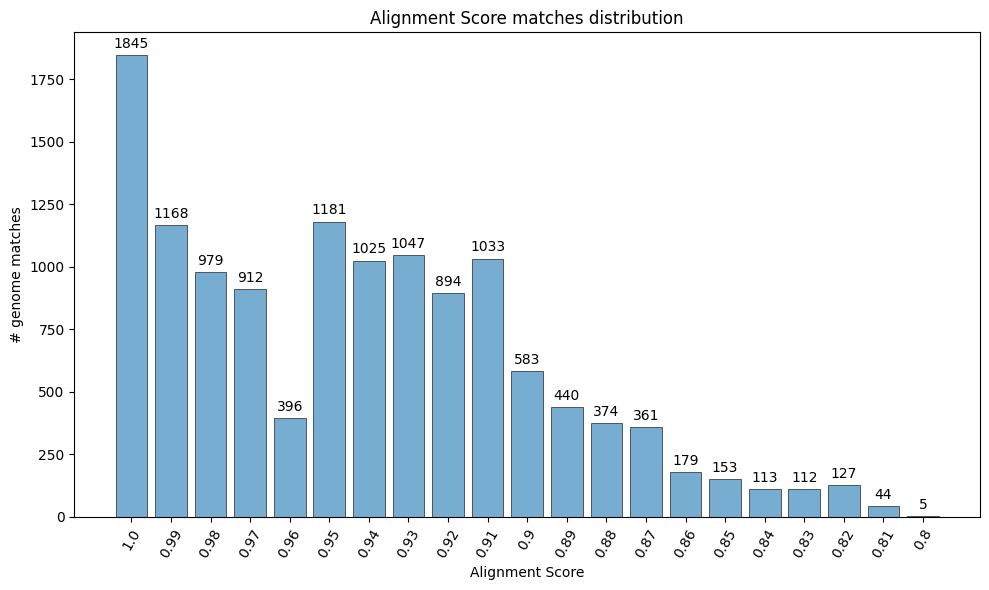

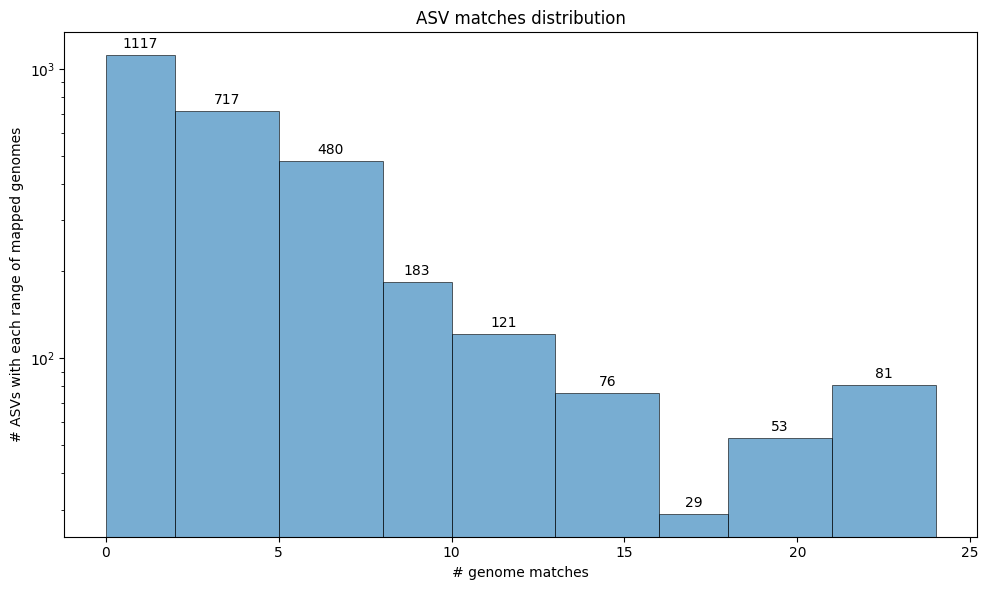

In [17]:
matches_to_get = load(open("modeling_files/matches_to_get.json", 'r'))

# examining matches per score
scoreMatches = {}
ASVMatches = {}
for ASV, content in matches_to_get.items():
    ASVMatches.setdefault(ASV, [])
    for score, md5s in content.items():
        ASVMatches[ASV].extend(md5s)
        scoreMatches.setdefault(score, [])
        scoreMatches[score].extend(md5s)

print(list(ASVMatches.items())[:2])

import matplotlib.pyplot as plt
from numpy import log10, logspace, linspace

dics = {"Alignment Score": scoreMatches, "ASV": ASVMatches}
for kind, dic in dics.items():
    fig, ax = plt.subplots(figsize=(10, 6))
    dic = {k: len(v) for k,v in dic.items()}
    if kind == "Alignment Score":
        dic = dict(sorted(dic.items(), key=lambda x: float(x[0]), reverse=True))
        # dic = {k: len(v) for k,v in dict(sorted(dic.items(), key=lambda x: float(x[0]), reverse=True)).items()}
        total = sum(dic.values())
        for i, (score, matches) in enumerate(dic.items()):
            print(score, sum(list(dic.values())[:i+1])/total)
        bars = ax.bar(list(dic.keys()), list(dic.values()), alpha=0.6, edgecolor='black', linewidth=0.7)
        ax.set_xlabel(kind)
        ax.set_ylabel('# genome matches')
        ax.bar_label(bars, fmt='%d', padding=3, fontsize=10)
        plt.xticks(rotation=60)
    elif kind == "ASV": 
        # for i, (label, values) in enumerate(dic.items()):
        # bins = [int(x) for x in logspace(0, log10(max(list(dic.values()))), 10)]
        bins = [int(x) for x in linspace(0, max(list(dic.values())), 10)]
        n, bins, patches = ax.hist(dic.values(), bins=bins, alpha=0.6, edgecolor='black', linewidth=0.7)
        ax.set_ylabel("# ASVs with each range of mapped genomes")
        ax.set_xlabel('# genome matches')
        ax.set_yscale('log')
        ax.bar_label(patches, fmt='%d', padding=3, fontsize=10)
        # This is the magic part:
        # ax.set_xscale('log')
        # ax.xaxis.set_major_formatter(plt.ScalarFormatter())   # show numbers, not 10^ 
        # ax.xaxis.set_minor_formatter(plt.ScalarFormatter())
        # ax.ticklabel_format(style='plain', axis='x') #, rotation=60)      # avoid scientific notation
    ax.set_title(f'{kind} matches distribution')
    # ax.legend()
    plt.tight_layout()
    plt.savefig(f'modeling_files/{kind}_distributions.png')
    plt.show()

# Pulling matched genomes from BV-BRC

## Determine ASVsets

In [18]:
from collections import Counter
from numpy import mean, std, array
from pandas import DataFrame
from json import load
from itertools import chain

matches_to_get = load(open("modeling_files/matches_to_get.json", 'r'))
IDmatches = {ID: list([x for y in matches.values() for x in y]) for ID, matches in matches_to_get.items()}
overlapping = {}
combining = {}
zeros = []
included = []
threshold = 0.2
for ID, matches in IDmatches.items():
    overlapping.setdefault(ID, {})
    for ID2, matches2 in IDmatches.items():
        if ID2 == ID or ID2 in overlapping.keys(): continue # or ID2 in included:   continue
        if len(set(matches)) == 0:  zeros.append(ID)  ;  continue
        if len(set(matches2)) == 0:  zeros.append(ID2)  ;  continue
        overlapping[ID][ID2] = len(set(matches) & set(matches2)) / len(set(matches) | set(matches2))
        if overlapping[ID][ID2] >= threshold:
            # print(ID, ID2, overlapping[ID][ID2])
            combining.setdefault(ID, [])
            combining[ID].append(ID2)
            # included.append(ID2)

# allocate an ASV to its best hitting ASVset
inverted_best = {}
for ID1, ID2s in combining.items():
    for ID2 in ID2s:
        score = overlapping.get(ID1, {}).get(ID2, float('-inf'))
        if score > overlapping.get(inverted_best.get(ID2, ''), {}).get(ID2, float('-inf')):
            inverted_best[ID2] = ID1
combining = {}
for ID2, ID1 in inverted_best.items():
    combining.setdefault(ID1, []).append(ID2)
    
combining_lengths = [len(v) for k,v in combining.items()]
print("ASVset stats:", round(mean(combining_lengths), 2), "+/-", round(std(combining_lengths), 2), "max", max(combining_lengths))
# display(combining)
dump(combining, open("modeling_files/ASV_sets.json", 'w'), indent=3)

print(len(zeros), len(set(zeros)), set(zeros))
overlapping_df = DataFrame.from_dict(overlapping)
overlaps = overlapping_df.to_numpy().flatten()
overlaps = overlaps[overlaps > 0]
# display(dict(sorted(Counter(overlaps).items(), key=lambda item: item[1], reverse=True)))
counted = dict(sorted(Counter(overlaps).items(), key=lambda item: item[0], reverse=True))
display(counted)
# print(round(mean(overlaps), 2), round(std(overlaps), 2), max(overlaps))

ASVset stats: 1.94 +/- 2.01 max 32
107825 38 {'2c76f558846fa9aa57c59ddacefeacb2', 'a012a92141e089dd0e178bc46889f8bd', '36f3b6d6951a802a6906a07bed8168bb', '26cbd70e0eb0b0a14e93c0970b305ef1', '6a639263c07c310881a6085392276536', 'd3648f626f4aadacf25eb043bdc62c58', '245b33b8928a2d472035cfcc336caddb', '26c822a9da99f48bc5eabddbeda2a1e8', '1f42391a983ba3af940e541d110a8432', '92862fbe6ff344c8964156b2a0b424cc', '475578087d74506dfa16ebf79e182c28', '60ec6b41425f294ba92e7b2f8cc23289', '0674e7934525d446c54c31dc9b8e33d5', '172df84126559d3703a3b6184b45a0ee', '822e596ebee53d4dcd5ffe3e26ec43d4', '2c8630b0baf30f2cc97a2f0b4bc96aca', '608bdffdf9263f1b123d069d10e69f9a', 'ad7b37d7259f65ae5d2d898c539a6297', '03a6a6d84a7be4b11b6467c91ca79d57', 'c2b43f5fc401b8ae942e9f83213eef32', '02541e05438ebd6cd913200972ef5e4b', '72c6706063e2325bd12c28ea8b23e872', 'df24931eef177828ec0d0b347ec6cf02', '6e252cae9e8ff5755e0cfa5c52a78beb', '593b39ccba286d62eba7872e07c45354', 'e61e6021af25969dd347b921fc6389a4', '46bd23bd0fd9dba10

{np.float64(1.0): 1778,
 np.float64(0.9333333333333333): 1,
 np.float64(0.9): 1,
 np.float64(0.8888888888888888): 7,
 np.float64(0.8823529411764706): 1,
 np.float64(0.875): 35,
 np.float64(0.8571428571428571): 48,
 np.float64(0.8333333333333334): 80,
 np.float64(0.8181818181818182): 7,
 np.float64(0.8076923076923077): 1,
 np.float64(0.8): 21,
 np.float64(0.7894736842105263): 1,
 np.float64(0.7857142857142857): 1,
 np.float64(0.7777777777777778): 10,
 np.float64(0.75): 179,
 np.float64(0.7368421052631579): 1,
 np.float64(0.7272727272727273): 10,
 np.float64(0.7142857142857143): 101,
 np.float64(0.7058823529411765): 1,
 np.float64(0.7): 32,
 np.float64(0.6923076923076923): 1,
 np.float64(0.6875): 3,
 np.float64(0.6666666666666666): 194,
 np.float64(0.6538461538461539): 1,
 np.float64(0.6470588235294118): 1,
 np.float64(0.6428571428571429): 3,
 np.float64(0.6363636363636364): 17,
 np.float64(0.631578947368421): 2,
 np.float64(0.6296296296296297): 1,
 np.float64(0.625): 97,
 np.float64(0.6

In [16]:
from json import load, dump
from numpy import mean, std, array

matches_to_get = load(open("modeling_files/matches_to_get.json", 'r'))
IDmatches = {ID: list([x for y in matches.values() for x in y]) for ID, matches in matches_to_get.items()}

ASV_sets = load(open("modeling_files/ASV_sets.json", 'r'))
redunant_asvs = {v:k for k,vs in ASV_sets.items() for v in vs}

# NOTE: This captures ASVsets
md5_ID = load(open("model_inputs/16S_md5_ID.json", 'r'))
ASV_genomes, ASV_genomeIDs = {}, {}
for ASV, contents in matches_to_get.items():
    ASV_genomes.setdefault(redunant_asvs.get(ASV, ASV), []).extend([x for xs in contents.values() for x in xs])
    ASV_genomeIDs.setdefault(redunant_asvs.get(ASV, ASV), []).extend(
        [md5_ID[x].split("|")[1].split(".rna")[0] for xs in contents.values() for x in xs])
print(list(ASV_genomes.items())[0], "\n\n")
dump(ASV_genomes, open("modeling_files/ASV_genomes.json", 'w'), indent=2)
dump(ASV_genomeIDs, open("modeling_files/ASV_genomeIDs.json", 'w'), indent=2)
    
print(len(redunant_asvs), len(redunant_asvs)/len(ASV_sets), mean(list(map(len, ASV_sets.values())))) #, redunant_asvs)
print(len(set(redunant_asvs)), f"ASVs are redundant, from", len(IDmatches), "total, and will be combined into", len(ASV_sets),
      "ASVsets, which will result in", len(IDmatches)-len(ASV_sets), len(ASV_genomes), "unique ASVs")
list(ASV_sets.items())[:2]

('0fec351445f84bd482075ceda6123f46', ['8919b57c55462472be46d7f4558dc68f', '271534eefd04da5c51a9f5523a87a45d', 'e2868484d4a7db6de599887368eba1c0', '17c560e843b457ca17880fb276a00b52', '27fee1316bda01e72e5e087721ee5d82', 'f19e6bdd5844ed3cb29bb1ebf488c149', '64300e7cd4d4a22317770eb0e63020ba', '8919b57c55462472be46d7f4558dc68f', '271534eefd04da5c51a9f5523a87a45d', 'e2868484d4a7db6de599887368eba1c0', '17c560e843b457ca17880fb276a00b52', '27fee1316bda01e72e5e087721ee5d82', 'f19e6bdd5844ed3cb29bb1ebf488c149', '64300e7cd4d4a22317770eb0e63020ba', '8919b57c55462472be46d7f4558dc68f', 'e2868484d4a7db6de599887368eba1c0', '17c560e843b457ca17880fb276a00b52', 'f19e6bdd5844ed3cb29bb1ebf488c149', '8919b57c55462472be46d7f4558dc68f', 'e2868484d4a7db6de599887368eba1c0', '17c560e843b457ca17880fb276a00b52', 'f19e6bdd5844ed3cb29bb1ebf488c149', '33694ba394cb9bcdf5d83c55b14549ad', '273846522f3916e1b62aa5f67ddb0006', '271534eefd04da5c51a9f5523a87a45d', '27fee1316bda01e72e5e087721ee5d82', '6a71bd4cf6652e8da42eb63ed

[('0fec351445f84bd482075ceda6123f46',
  ['2c1453fb27de0eb5e19ae61028df3294',
   '534d7b1bce2cf035866320576094f81e',
   '136c27e1efa2b99fb71cdff938615daa',
   '0e941c919146c9d562604083a4eeadc8',
   '1d808a941e29c1b4f33534431001dd27']),
 ('534d7b1bce2cf035866320576094f81e',
  ['9e67f564a732feffc50f5fc690ec2e71',
   'b4ac0621ed68fda2b501520e951949e1',
   'c6d0e484e529a485ffc0b1f08f1fb158',
   'c1795fae23a34030462cf6e6267b85b3',
   'a214ccee6e9a8749c048daa053ae51dc',
   '4e39e7f278e094156ebfcc28868dd7dd',
   'e04d49b3a01d91878d1c27f4e22b074e',
   '3ab03e560dde34c45b0a4e71c809c190',
   '48583aa878619934f2f6d8583cccae68',
   '50f6937d35cf193c1881b6fb7c273225',
   'a049ac86c03db7991ef693a1bb025681',
   '7c6299b064794dfea9e563a4645d1bbf',
   'b513381a51c3d1b0d7e568a804954430',
   '270c5d9a2223e0f5d99547e426bc19e4',
   '5c52186b7c44d5709af099adc5dea216',
   '5b02c8639023ea8693ddee6bf1597c70',
   '85a27e670e0e57e67484195e26028b19',
   'be437fdb39ff4822fcaf0522cbd7c1e0',
   '451f992938efa5e0c6523

In [28]:
from json import load, dump

ASV_sets = load(open("modeling_files/ASV_sets.json", 'r'))
redunant_asvs = {v:k for k,vs in ASV_sets.items() for v in vs}

abundances = load(open("model_inputs/abundances.json", 'r'))
ASVset_abundances = {}
for sample, content in abundances.items():
    ASVset_abundances[sample] = {}
    total_abundance = sum(content.values())
    for ID, abundance in content.items():
        abundance /= total_abundance
        primaryASV = redunant_asvs.get(ID, ID)
        ASVset_abundances[sample].setdefault(primaryASV, 0)
        ASVset_abundances[sample][primaryASV] += abundance

# copy = {k:v for k,v in ASVset_abundances.items()}
skipped, not_skipped = 0, 0
for sample, content in ASVset_abundances.items():
    ogContent = len(content)
    skipping = set()
    for ID, abundance in content.items():
        if abundance < 0.001:
            skipping.add(ID)
    # print(sample, len(ASVset_abundances[sample]))
    for ID in skipping:
        ASVset_abundances[sample].pop(ID)
    # print(len(ASVset_abundances[sample]))
    skipped += len(skipping)
    not_skipped += (ogContent-len(skipping))

print(skipped, "sample ASVs were skipped, to produce", not_skipped, "sample ASVs")
dump(ASVset_abundances, open("modeling_files/ASVset_abundances.json", 'w'))

31937 sample ASVs were skipped, to produce 1047 sample ASVs


## visualizing ASVset data

### abundance distributions

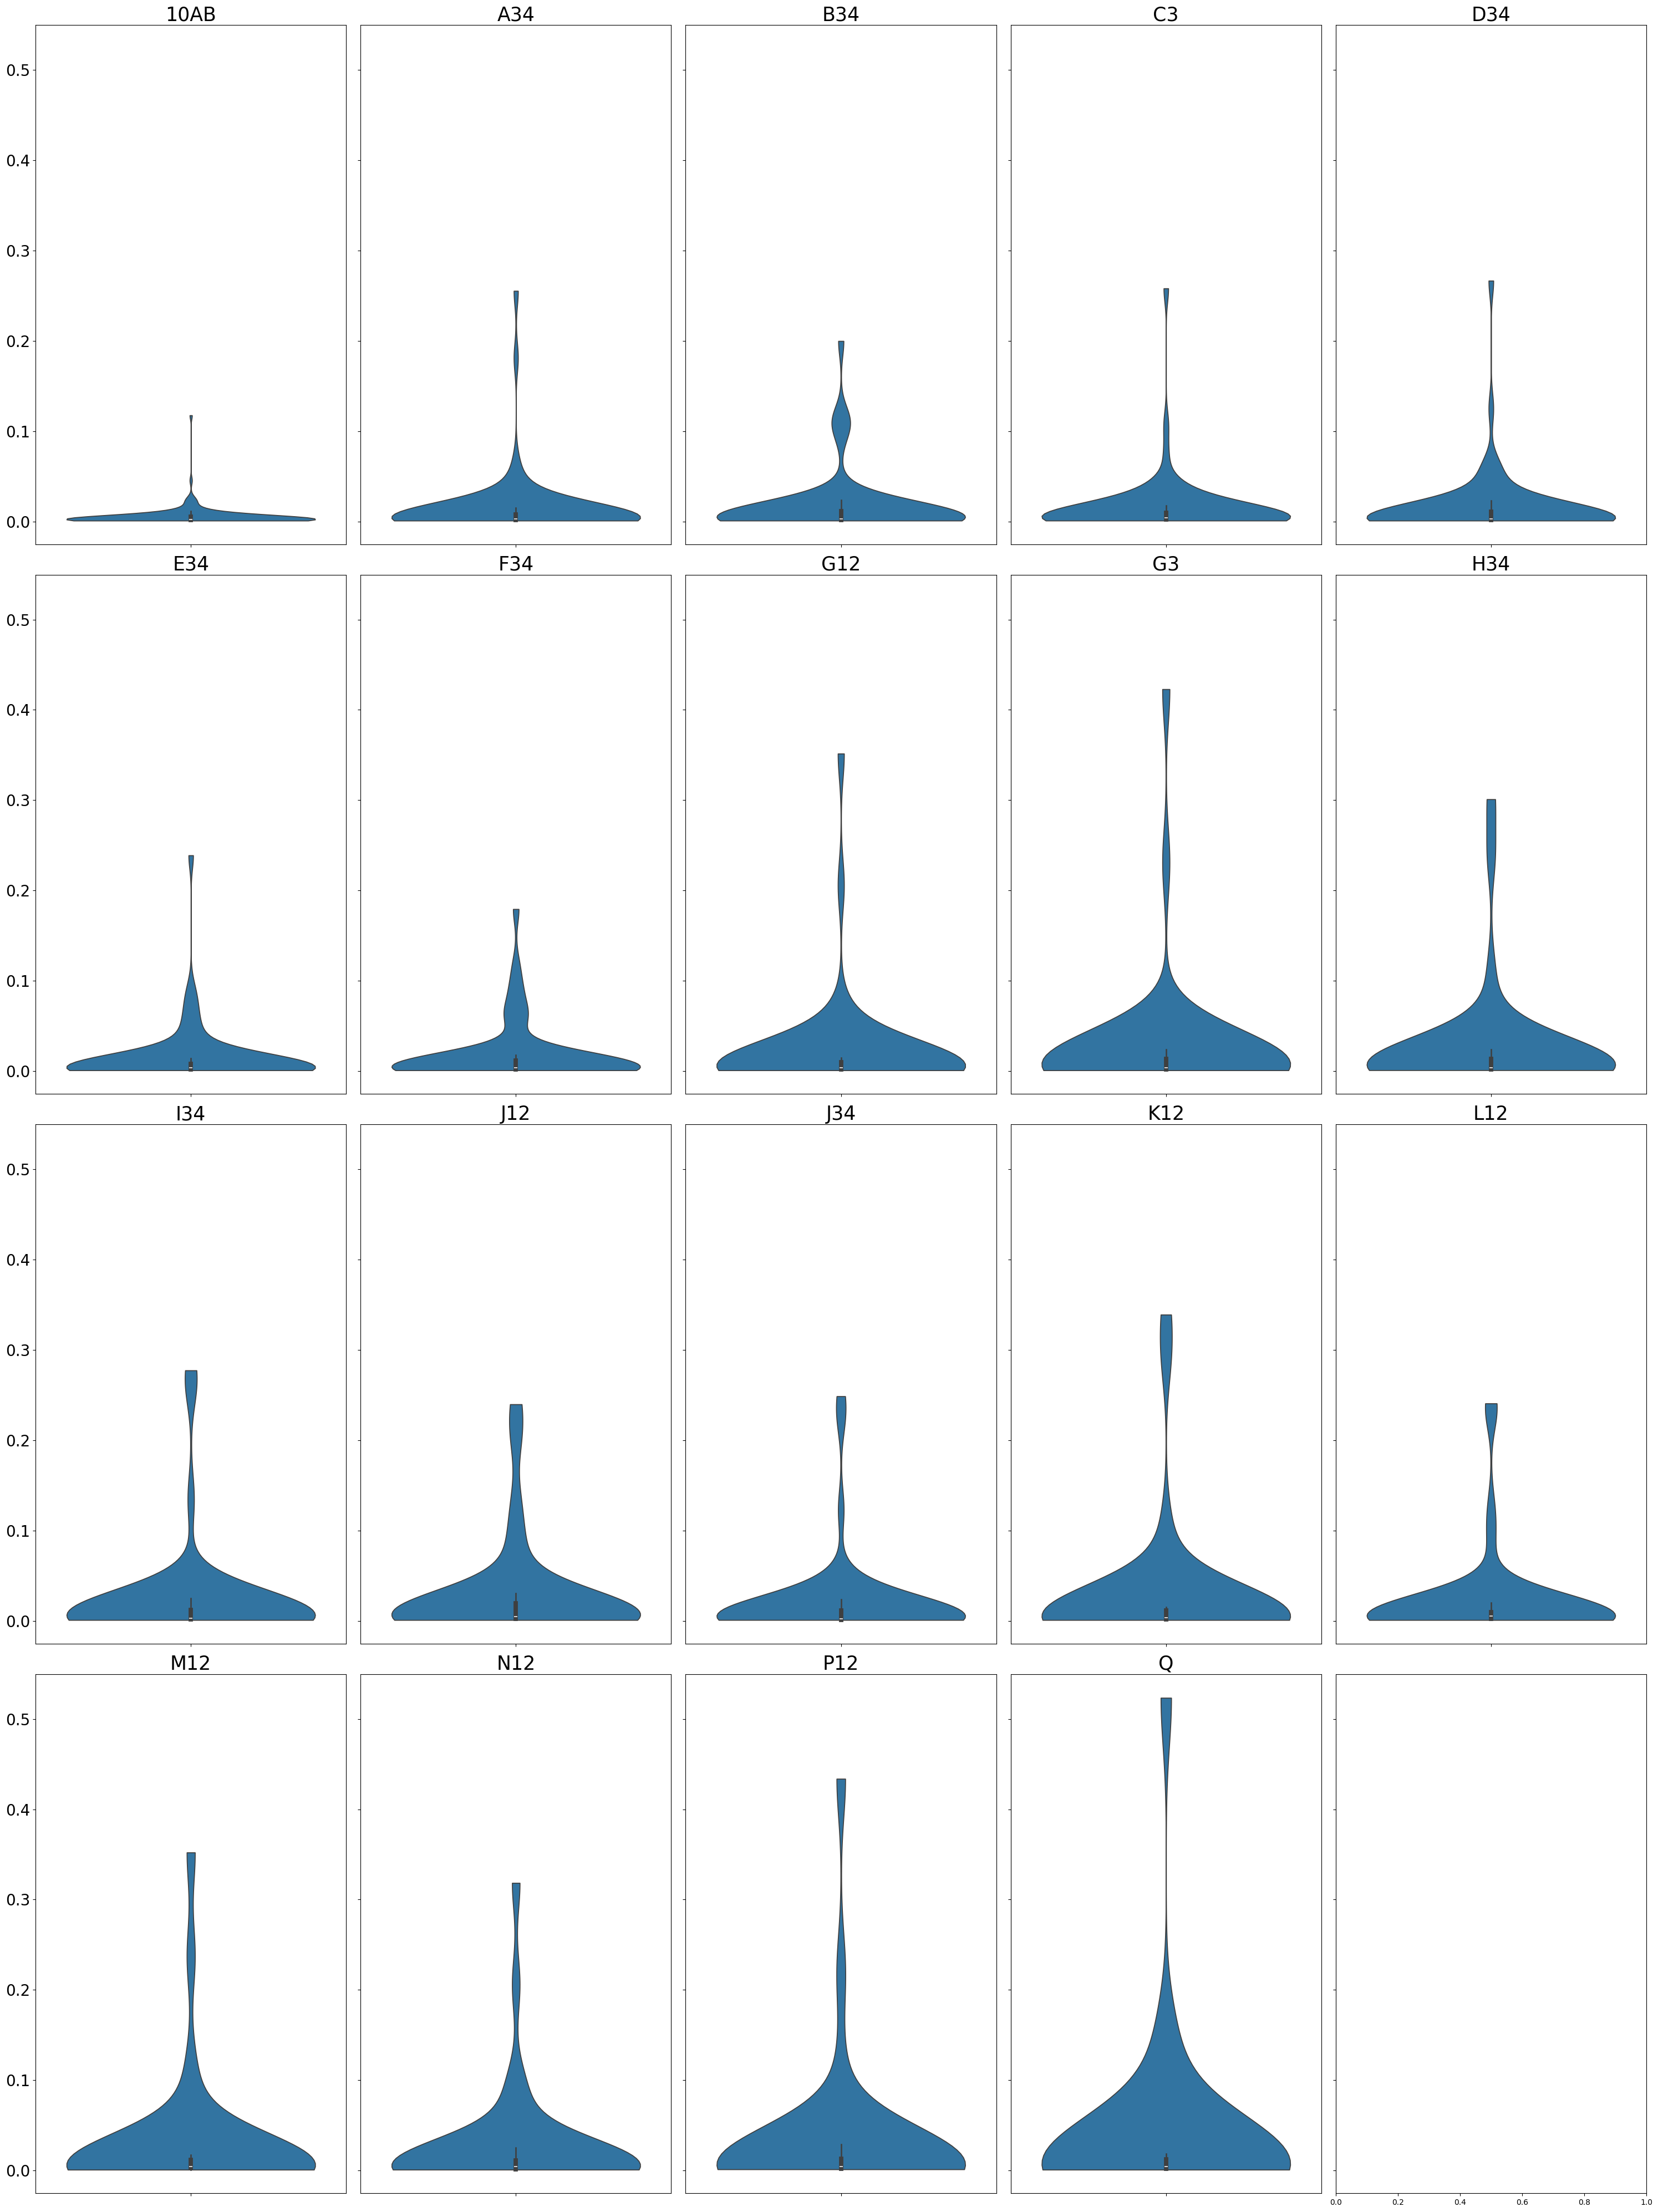

In [39]:
import matplotlib.pyplot as plt
from pandas import Series
from json import load, dump
from numpy import mean, std
from numpy import array
import seaborn as sns

ASVset_abundances = load(open("modeling_files/ASVset_abundances.json", 'r'))
columns = 5
fig, axes = plt.subplots(4, columns, figsize=(30, 40), sharey=True)
for i, (sample, ASVabun) in enumerate(ASVset_abundances.items()):
    abundances = ASVabun.values()
    # print(sample, Series(abundances).describe())
    # print()

    # Create subplots
    col_count = i//columns
    i = i%columns
    ax = axes[col_count, i]
    sns.violinplot(y=abundances, cut=0, ax=ax)#, density_norm='width')
    ax.set_title(f"{sample}", fontsize=25)
    # axes[i].set_xlabel("")
    # axes[i].set_ylabel("")
    ax.tick_params(axis='y', labelsize=20)

# axes[0].set_ylabel("Value")  # only left-most gets y-label
plt.tight_layout()
plt.savefig("modeling_files/ASVset_abundance_distributions.png")
plt.show()

### genome mapping distribution

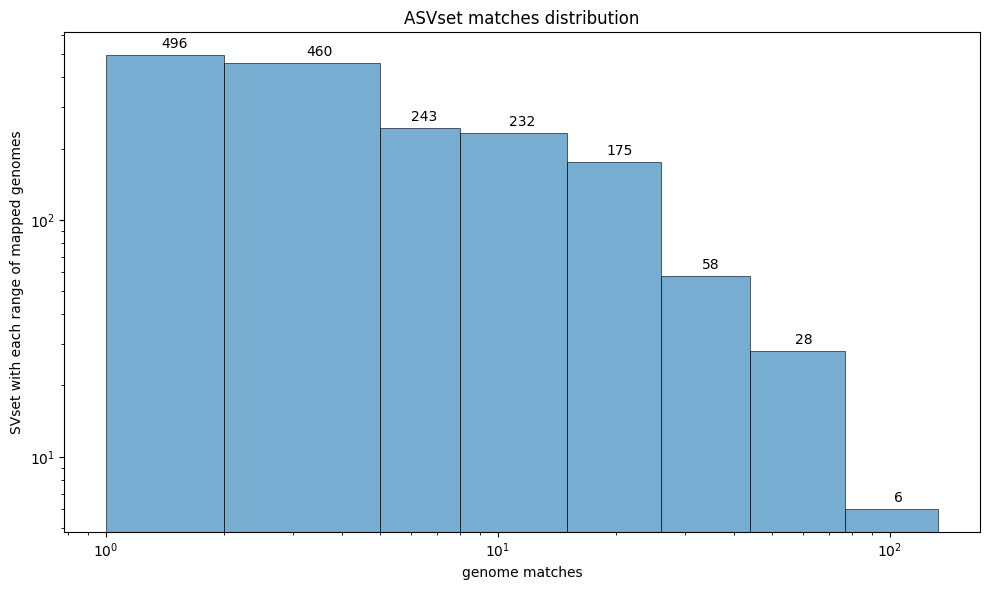

In [6]:
import matplotlib.pyplot as plt
from numpy import linspace, logspace, log10
from json import load

ASV_genomes = load(open("modeling_files/ASV_genomes.json", 'r'))
dic = {k: len(v) for k,v in ASV_genomes.items()}
bins = [int(x) for x in logspace(0, log10(max(list(dic.values()))), 10)]
fig, ax = plt.subplots(figsize=(10, 6))
# bins = [int(x) for x in linspace(0, max(list(dic.values())), 10)]
n, bins, patches = ax.hist(dic.values(), bins=bins, alpha=0.6, edgecolor='black', linewidth=0.7)
ax.set_ylabel("SVset with each range of mapped genomes")
ax.set_xlabel('genome matches')
ax.set_yscale('log')
ax.set_xscale('log')
ax.bar_label(patches, fmt='%d', padding=3, fontsize=10)
ax.set_title(f'ASVset matches distribution')
# ax.legend()
plt.tight_layout()
plt.savefig(f'modeling_files/ASVset_distributions.png')
plt.show()

### abundance distribution

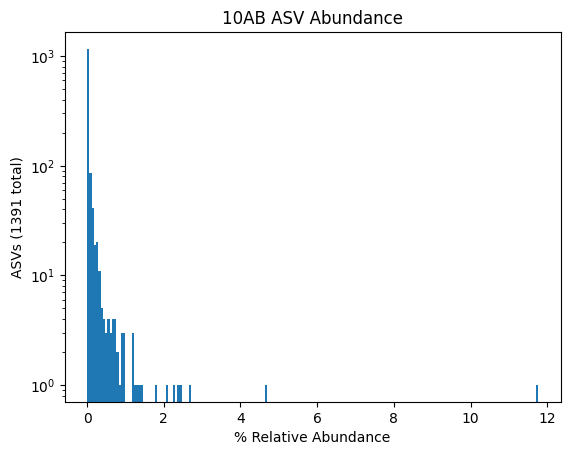

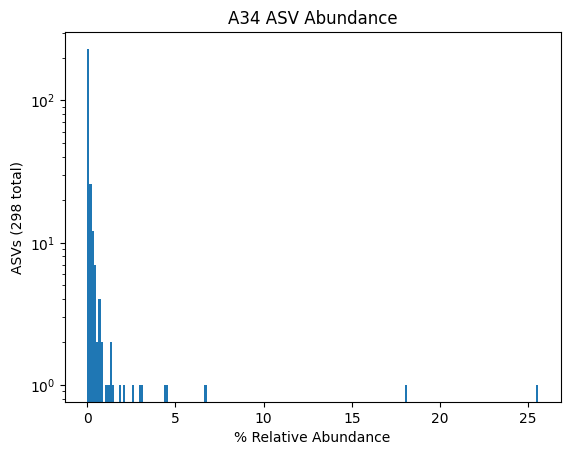

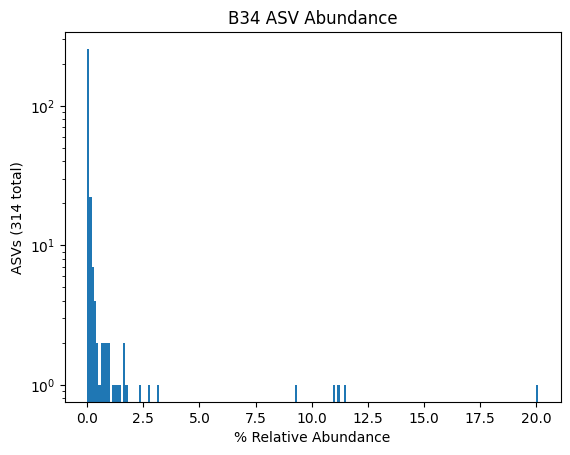

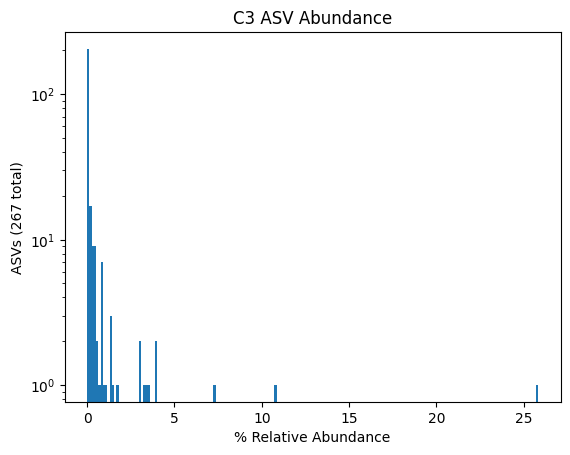

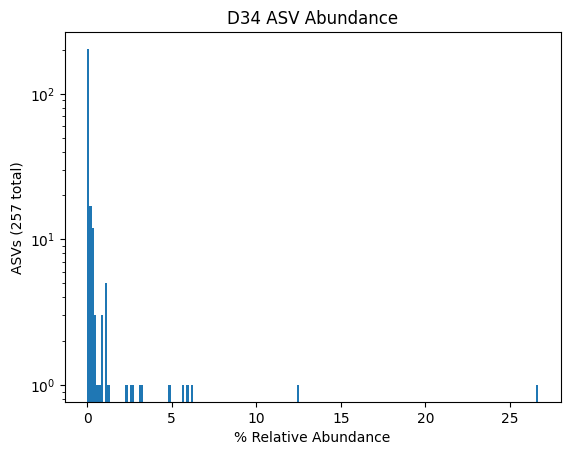

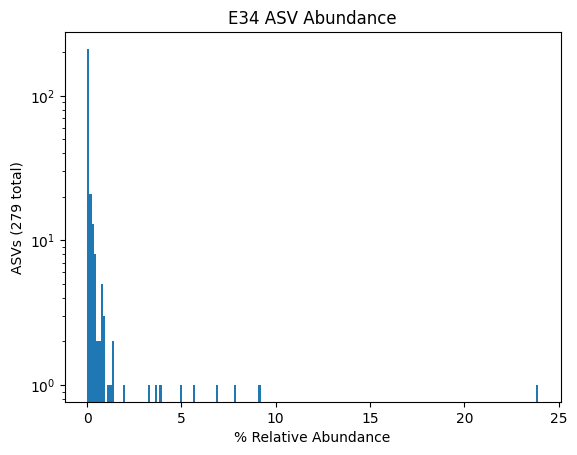

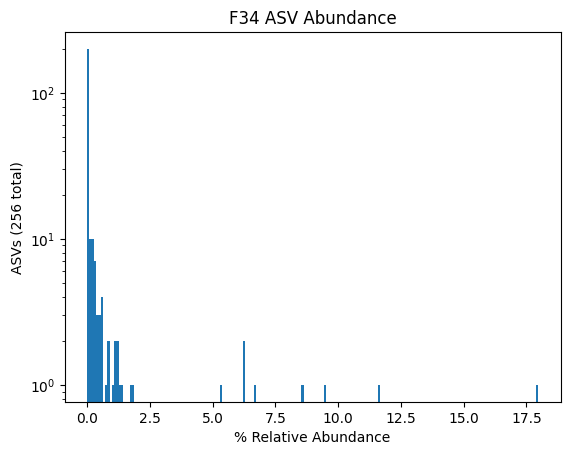

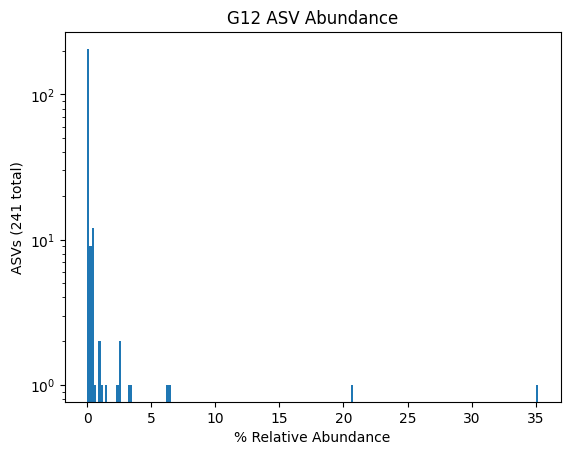

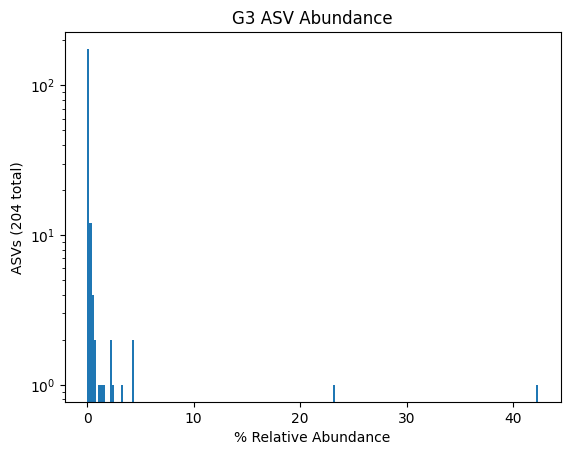

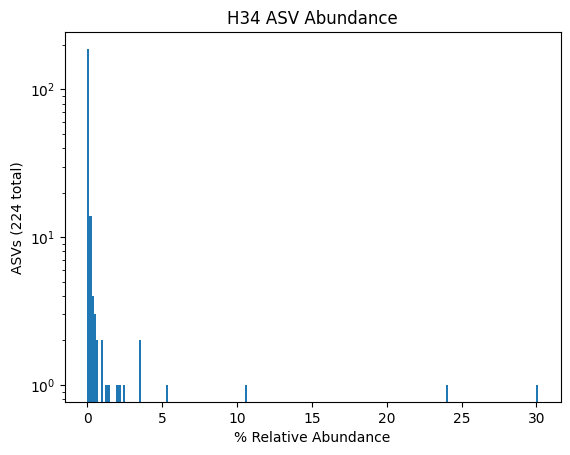

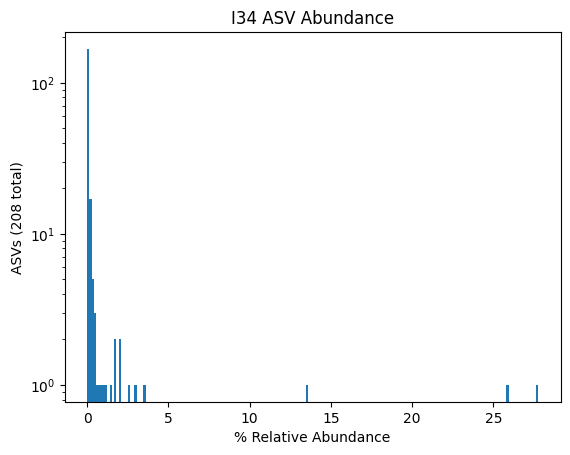

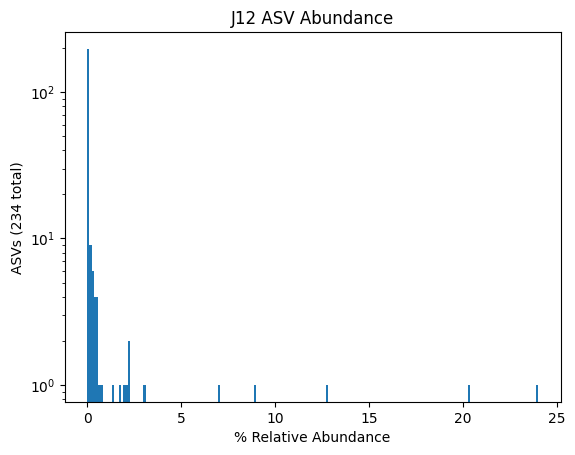

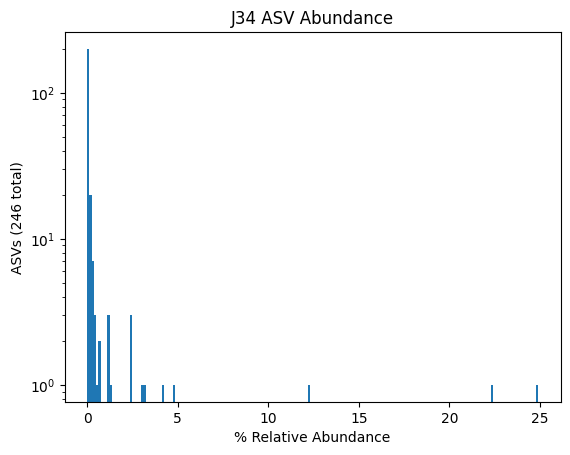

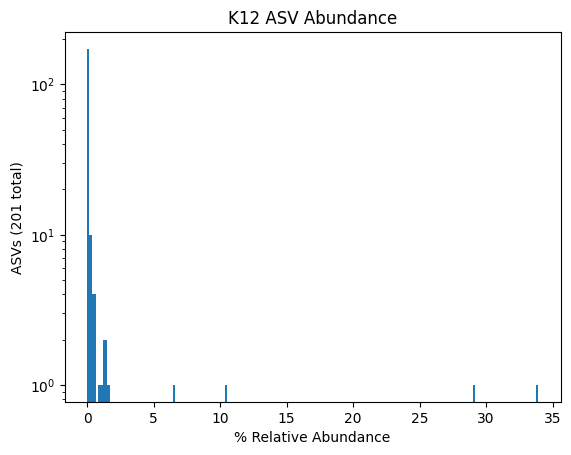

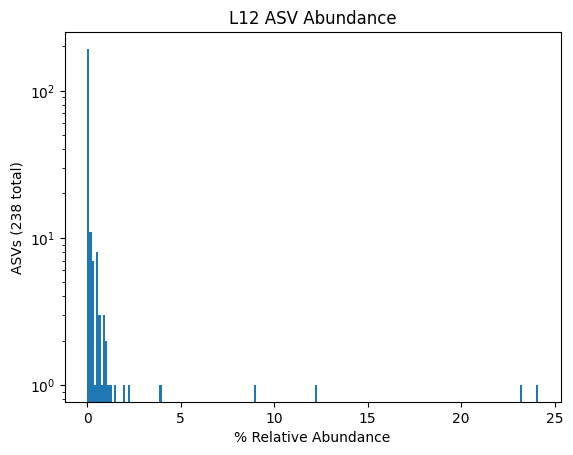

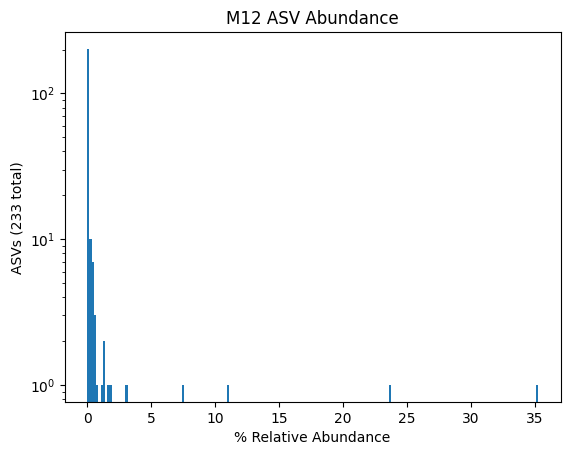

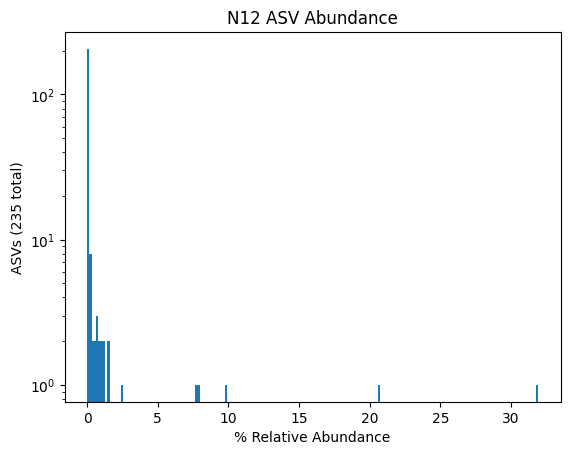

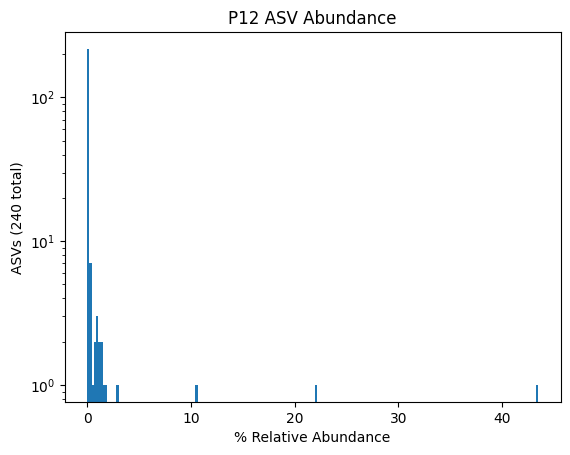

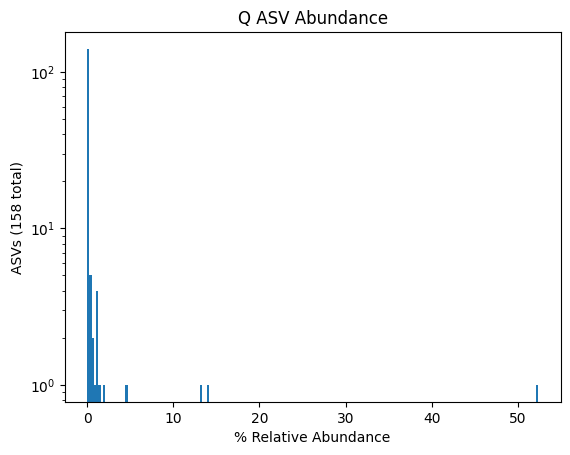

In [22]:
import matplotlib.pyplot as plt
from json import load

ASVset_abundances = load(open("modeling_files/ASVset_abundances.json", 'r'))
for sample, content in ASVset_abundances.items():
    # print(sample)
    abundances = [x for x in list(content.values()) if x > 0]
    plt.hist(abundances, bins=200)

    # Add labels and title
    plt.xlabel('% Relative Abundance')
    plt.ylabel(f'ASVs ({len(abundances)} total)')
    plt.yscale('log')
    plt.title(f'{sample} ASV Abundance')

    # Display the plot
    plt.savefig(f'abundance_distributions/{sample}_ASVset_abundance.png')
    plt.show()

# downloading genomes and features

In [2]:
from json import load,dump
from tqdm import tqdm
import urllib.parse as parse
import requests
import time, os

md5_ID = load(open("model_inputs/16S_md5_ID.json", 'r'))
# ASV_genomes = load(open("modeling_files/ASV_genomes.json", 'r'))
ASV_genomeIDs = load(open("modeling_files/ASV_genomeIDs.json", 'r'))
all_genomes = set([g for ASV, IDs in ASV_genomeIDs.items() for g in IDs])
print(len(all_genomes), "total genomes")

empty = []

# for genomeID in tqdm(all_genomes, total=len(all_genomes)):
def pull_content(genomeID):
    # genomeID = genomeID.split("|")[1].split(".rna")[0]
    
    # Metadata (Taxonomy)
    url_genomeID = parse.quote(genomeID, safe='')
    if os.path.exists(f"genome_metadata/{genomeID}.json"):
        return
    genome_url = (f"https://www.bv-brc.org/api/genome/"
                f"?eq(genome_id,{url_genomeID})")
                # "&select(kingdom,phylum,class,order,family,genus,species)"
                # "&limit(20000)&http_accept=application/json")
    try:
        genome = requests.get(genome_url).json()
    except:
        try:
            # Wait 5 seconds
            time.sleep(2)
            genome = requests.get(genome_url).json()
        except:
            print(f"The {genomeID} features page cannot opened again")
            return #continue
    dump(genome[0], open(f"genome_metadata/{genomeID}.json", 'w'))
    
    # Genome sequence
    if os.path.exists(f"genomes/{genomeID}.fna"):
        return #continue
    # print(genomeID, url_genomeID)
    url = (
        "https://www.bv-brc.org/api/genome_sequence/"
        f"?eq(genome_id,{url_genomeID})"
        "&select(accession,sequence)"
        "&limit(100000)"
    )
    r = requests.get(url, headers={"Accept": "application/json"})
    try:
        r.raise_for_status()
    except:
        print(f"The {genomeID} genome page cannot open: {r.url}")
        try:
            r = requests.get(url, headers={"Accept": "application/json"})
        except:
            print(f"The {genomeID} genome page cannot open again")
            return #continue
    # print(r.text)
    content = r.json()
    if not content:
        empty.append(genomeID)
    display([x.keys() for x in content])

    ## Write FASTA
    with open(f"genomes/{genomeID}.fna", "w") as out:
        for c in content:
            # print(c)
            out.write(f">{c['accession']}\n{c['sequence']}\n")

    # Features
    if os.path.exists(f"features/{genomeID}.json"):
        # print("existing features")
        return #continue
    feat_url = (f"https://www.bv-brc.org/api/genome_feature/"
                f"?eq(genome_id,{genomeID})"
                "&select(patric_id,pgfam_id,plfam_id,figfam_id,product,feature_type,annotation,go,og_id,sog_id)"
                "&limit(20000)&http_accept=application/json")
    try:
        feats = requests.get(feat_url).json()
    except:
        try:
            # Wait 5 seconds
            time.sleep(2)
            feats = requests.get(feat_url).json()
        except:
            print(f"The {genomeID} features page cannot opened again")
            return #continue
    dump(feats, open(f"features/{genomeID}.json", 'w'))


parallelize = False
if parallelize:
    # parallelize the effort
    from multiprocess import Pool
    from os import cpu_count
    
    cpus = int(cpu_count()/8)
    print(f"{cpus} cores are being used.  The first argument is {args[0]}")
    pool = Pool(cpus)
    outputs = pool.map(pull_content, all_genomes)
else:
    for ID in tqdm(all_genomes):
        output = pull_content(ID)
        # print(output)
        # break

5430 total genomes


100%|██████████| 5430/5430 [11:43<00:00,  7.71it/s]   


In [9]:
# from glob import glob 
# from json import load

# features = glob(f"features/*.json")
# missing_features = []
# for path in features:
#     genomeID = path.split("/")[-1].replace(".json", '')
#     if genomeID not in all_genomes:
#         missing_features.append(genomeID)
# print(len(missing_features), "are extra from", len(features), "features")

# genomes = glob(f"genomes/*.fna")
# missing_genomes = []
# for path in genomes:
#     genomeID = path.split("/")[-1].replace(".fna", '')
#     if genomeID not in all_genomes:
#         missing_genomes.append(genomeID)
# print(len(missing_genomes), "are missing from", len(genomes), "genomes")

# print(set(missing_features).symmetric_difference(set(missing_genomes)))

## determining feature probabilities

In [3]:
from collections import Counter
from glob import glob
from json import load
from numpy import mean

ASV_genomeIDs = load(open("modeling_files/ASV_genomeIDs.json", "r"))
# no_features = []
# errors = []
for att in ["product", "pgfam_id", "plfam_id"]:
    probabilities = {}
    maxes = []
    for ASV, IDs in ASV_genomeIDs.items():
        probabilities[ASV] = []
        features = []
        hits = len(IDs)
        for ID in IDs:
            genome_path = f"features/{ID}.json"
            if not os.path.exists(genome_path):
                print("missing", genome_path)
                continue
            with open(genome_path, 'r') as json_file:
                try:
                    feats = set([f.get(att, None) for f in load(json_file)])
                    feats.remove(None)
                    features.extend(list(feats))
                except Exception as e:
                    # errors.append((genomeID, str(e)))
                    # print(f"Error loading features for {genomeID}: {e}")
                    pass
    
        counted = Counter(features)
        probabilities[ASV] = {k:v/hits for k,v in counted.items()}
        if len(probabilities[ASV]) == 0:
            # no_features.append(amplicon)
            continue
        # print(list(probabilities[amplicon].values())[:5])
        maxes.append(max(probabilities[ASV].values()))
        # print(amplicon, hits, len(features), max(probabilities[amplicon].values()), min(probabilities[amplicon].values()))
        # break
    
    dump(probabilities, open(f"modeling_files/{att}_probabilities.json", 'w'), indent=2)

product_probabilities 8219463 total entries
mean product_probabilities probability 0.47 +/- 0.37 ; range 0.01 - 1.0

pgfam_id_probabilities 6408022 total entries
mean pgfam_id_probabilities probability 0.44 +/- 0.39 ; range 0.01 - 1.0

plfam_id_probabilities 5474107 total entries
mean plfam_id_probabilities probability 0.29 +/- 0.32 ; range 0.01 - 1.0



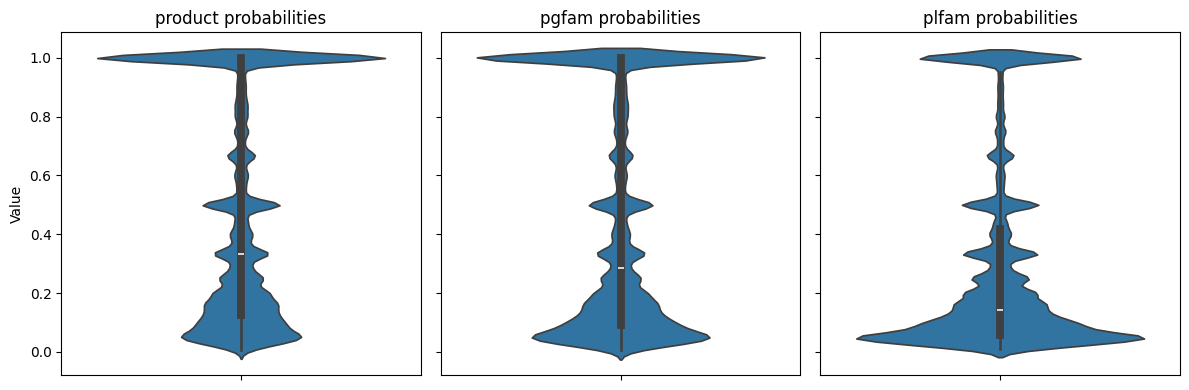

In [4]:
import matplotlib.pyplot as plt
from json import load, dump
from numpy import mean, std
from numpy import array
from glob import glob
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for i, prob_path in enumerate(glob(f"modeling_files/p*_probabilities.json")):
    f = load(open(prob_path, 'r'))
    att = prob_path.split("/")[-1].split(".")[0]
    probs = [p for ASV,v in f.items() for enzyme, p in v.items()]
    
    print(att, len(probs), "total entries")
    print(f"mean {att} probability", round(mean(probs),2), "+/-", round(std(probs),2),
          "; range", round(min(probs),2), "-", round(max(probs),2))
    print()

    # Create subplots
    sns.violinplot(y=probs, ax=axes[i])
    axes[i].set_title(f"{att.replace('_', ' ').replace('id ', '')}")
    # axes[i].set_xlabel("")
    # axes[i].set_ylabel("")

axes[0].set_ylabel("Value")  # only left-most gets y-label
plt.tight_layout()
plt.savefig("modeling_files/probability_distributions")
plt.show()

# creating synthetic genomes

In [3]:
from bvbrc_to_kbase_genome import LocalGenomeConverter
from json import load
import os

ASV_genomeIDs = load(open('modeling_files/ASV_genomeIDs.json', 'r'))
iterativeIDs = load(open('modeling_files/iterativeIDs.json', 'r'))
# ASV_genomes = load(open('modeling_files/ASV_genomes.json', 'r'))
# md5_ID = load(open("model_inputs/md5_ID.json", 'r'))
# all_genomes = set([md5_ID[g] for ASV, md5s in ASV_genomes.items() for g in md5s])

converter = LocalGenomeConverter()
missing_iterativeIDs, missing_IDs = [], []
# for asv_md5, IDs in list(ASV_genomes.items()):
missing_genomes = []
def create_synthetic_genome(item):
    (asv_md5, IDs) = item
    asv_id = iterativeIDs.get(asv_md5)
    # print(asv_id)
    if os.path.exists(f"genome_objects/{asv_id}.json"):
        return
    if len(IDs) == 0:
        missing_genomes.append(asv_md5)
        return
    # print(asv_id)
    if "." not in IDs[0]:
        for i, ID in enumerate(IDs):
            if ID not in md5_ID:
                missing_IDs.append(ID)
                return #continue
            IDs[i] = md5_ID[ID]
    if not asv_id:
        missing_iterativeIDs.append(asv_md5)
        # return # continue
    # genome_files = [f'genomes/{gid}.json' for gid in genome_ids]
    # try:
    synthetic = converter.create_synthetic_genome(
        asv_id=asv_id,
        genome_ids=IDs,
        taxonomy='Bacteria',  # Update with actual taxonomy
        template_file="modeling_inputs/TemplateGenome.json",
        verbose=False
    )
    print(f"Created {asv_id}: {len(synthetic['features'])} unique features")
    # except Exception as e:
    #     print(f"Failed {asv_id}: {e}")



# parallelize the effort
args = list(ASV_genomeIDs.items())#[:2]
print(len(args), "will be processed")
parallelize = False
if parallelize:
    from multiprocess import Pool
    from os import cpu_count
    
    cpus = int(cpu_count()/8)
    print(f"{cpus} cores are being used.  The first argument is {args[0]}")
    pool = Pool(cpus)
    outputs = pool.map(create_synthetic_genome, args)
    
    print(f"missing iterativeIDs", missing_iterativeIDs)
    print(f"missing IDs", missing_IDs)
else:
    for arg in args:
        # print(arg)
        create_synthetic_genome(arg)
        
print(list(map(iterativeIDs.get, missing_genomes)), " have no genomeIDs")

1736 will be processed
['Bacteria.26', 'midas_g_33170.2', 'Bacteria.11', 'Bacteria.15', 'midas_g_33170.1', 'Bacteria.24', 'Bacteria.18', 'midas_g_113571.1', 'Bacteria.23', 'Bacteria.20', 'midas_g_3582.1', 'Bacteria.27', 'Bacteria.16', 'Bacteria.3', 'Bacteria.9', 'Bacteria.10', 'Bacteria.7', 'Bacteria.6', 'midas_g_74815.1', 'Bacteria.12', 'Bacteria.25', 'Ca_Woesebacteria.1', 'midas_g_33170.3', 'Bacteria.4', 'Bacteria.17', 'midas_g_3701.1', 'Bacteria.8', 'Bacteria.22', 'Bacteria.28', 'Bacteria.19', 'midas_g_2290.1', 'Bacteria.30', 'midas_g_90235.1', 'midas_g_46393.1', 'Nannochloropsis_limnetica.1', 'Bacteria.29', 'Bacteria.13', 'Bacteria.14']  have no genomeIDs


### Visualize GC and functional distribution among the members

Exporting summary for 1698 genomes to genome_summary.tsv
Summary exported to genome_summary.tsv

Genome summary table (1698 genomes):


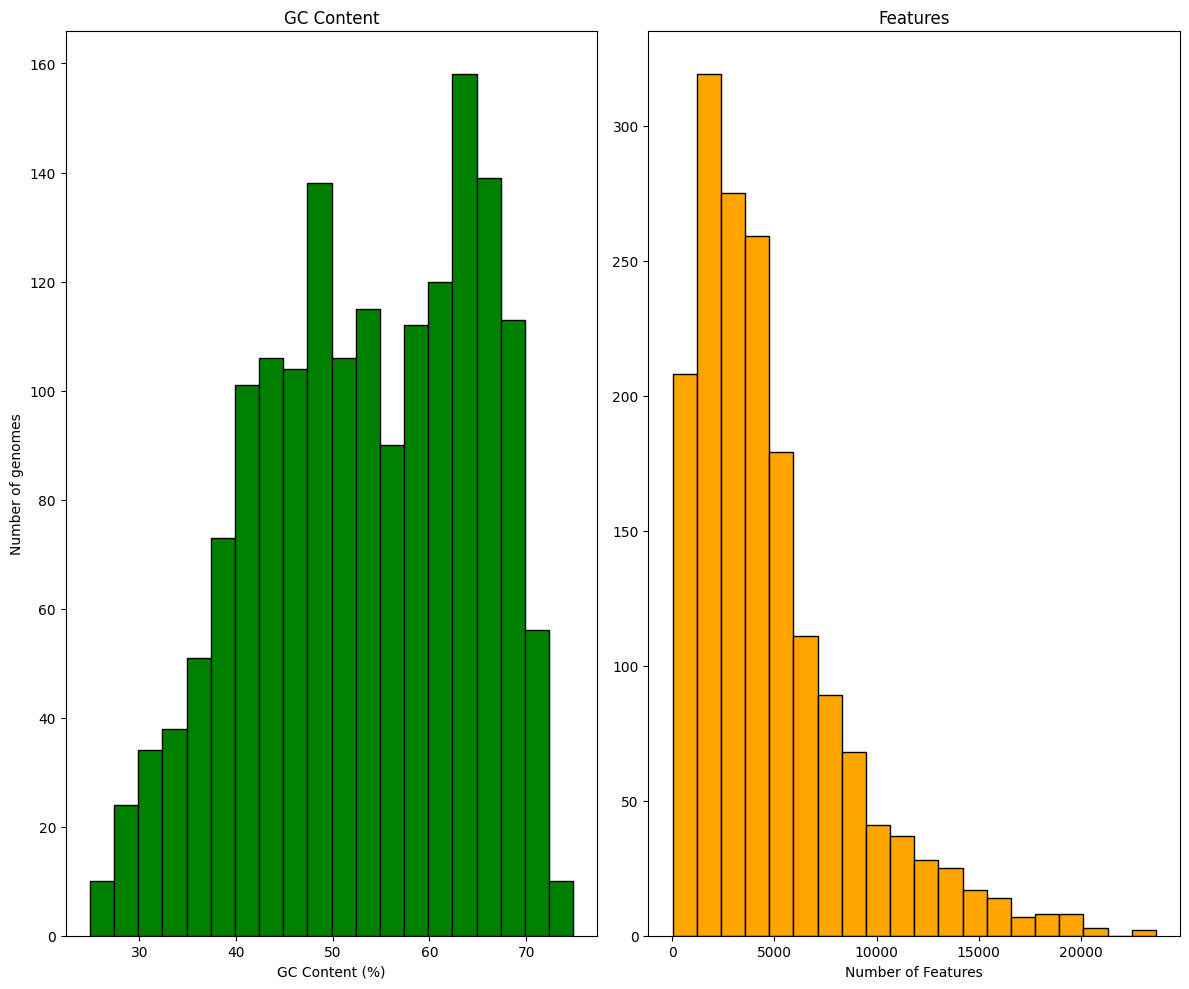

In [2]:
import matplotlib.pyplot as plt
from load_genomes_to_modelseedpy import export_genome_summary
import pandas as pd
import json


df = export_genome_summary('genome_summary.tsv', printing=False)
# df = pd.read_csv('genome_summary.tsv', sep='\t')
print(f"\nGenome summary table ({len(df)} genomes):")

fig, axes = plt.subplots(1, 2, figsize=(12, 10))
# DNA size distribution
# axes[0, 0].hist(df['dna_size'] / 1e6, bins=20, edgecolor='black')
# axes[0, 0].set_xlabel('Genome Size (Mbp)')
# axes[0, 0].set_ylabel('Count')
# axes[0, 0].set_title('Distribution of Genome Sizes')

# GC content distribution
axes[0].hist(df['gc_content'] * 100, bins=20, edgecolor='black', color='green')
axes[0].set_xlabel('GC Content (%)')
axes[0].set_ylabel('Number of genomes')
axes[0].set_title('GC Content')

# Number of features
axes[1].hist(df['num_features'], bins=20, edgecolor='black', color='orange')
axes[1].set_xlabel('Number of Features')
# axes[1].set_ylabel('Number of genomes')
axes[1].set_title('Features')

# Domain distribution
# domain_counts = df['domain'].value_counts()
# axes[1, 1].pie(domain_counts.values, labels=domain_counts.index, autopct='%1.1f%%')
# axes[1, 1].set_title('Distribution by Domain')

plt.tight_layout()
plt.savefig("genome_objects/genomic_stats.png")

In [154]:
# from pandas import DataFrame, Series
# from collections import Counter
# from json import load, dump

# matches_to_get = load(open("modeling_files/matches_to_get.json", 'r'))
# md5_geneIDs = load(open("model_inputs/16S_md5_ID.json", 'r'))
# taxonomy = load(open("model_inputs/taxonomy.json", 'r'))
# # midas_taxonomy = load(open("/Users/andrewfreiburger/Documents/Research/MicrobiomeNotebooks/digestor/new_taxonomy.json", 'r'))

# # Identify the genome IDs and their taxa
# match_genomes_counts = {}
# match_genomes = {}
# level = "Family"
# for ASV, contents in matches_to_get.items():
#     print(ASV)
#     match_genomes_counts.setdefault(ASV, [])
#     match_genomes.setdefault(ASV, [])
#     for score, md5s in contents.items():
#         for md5 in md5s:
#             genomeID = md5_geneIDs.get(md5, None)
#             if genomeID is None:
#                 print(md5, "is missing from md5_ID")
#             # genomeID = md5_geneIDs[md5].split("|")[1].split(".rna")[0]
#             taxa = taxonomy.get(md5)
#             if not taxa:
#                 print(md5, "is missing taxonomy")
#                 continue
#             taxa_level = taxa.get(level)
#             if not taxa_level:
#                 print(genomeID, "is missing the", level, "taxonomical level")
#                 continue
#             print(taxa_level)
#             match_genomes_counts[ASV].append(taxa_level)
#             match_genomes[ASV].append(genomeID)
#     match_genomes_counts[ASV] = dict(Counter(match_genomes_counts[ASV]).most_common())
# dump(match_genomes, open("modeling_files/match_genomes.json"))

# # Create the genome counts for each ASV
# midas_taxonomy = load(open("model_inputs/taxonomy.json", 'r'))
# match_genomes_df = DataFrame({k: Series(v) for k, v in match_genomes_counts.items()}).T
# match_genomes_df.index = [midas_taxonomy[i][level] for i in match_genomes_df.index]
# match_genomes_df.index.name = f"Midas {level}"
# match_genomes_df = match_genomes_df.groupby(level=0).sum()
# # match_genomes_df = DataFrame(match_genomes)
# display(match_genomes_df)

# match_genomes_js = {}
# for midas, content in match_genomes_df.T.to_dict().items():
#     series = Series(content)
#     series = series[series > 0]
#     match_genomes_js[midas] = {k: int(v) for k, v in sorted(series.to_dict().items(), key=lambda item: item[1], reverse=True)}

# display(match_genomes_js)
# util.save("match_genomes_counts", match_genomes_js)


# list(match_genomes.items())[:5]
# # list(matches_to_get.items())

0fec351445f84bd482075ceda6123f46
27fee1316bda01e72e5e087721ee5d82 is missing taxonomy
8919b57c55462472be46d7f4558dc68f is missing taxonomy
e2868484d4a7db6de599887368eba1c0 is missing taxonomy
64300e7cd4d4a22317770eb0e63020ba is missing taxonomy
f19e6bdd5844ed3cb29bb1ebf488c149 is missing taxonomy
271534eefd04da5c51a9f5523a87a45d is missing taxonomy
17c560e843b457ca17880fb276a00b52 is missing taxonomy
fde5fbd4507f68a2eabc92fb449d9965
27a062f922bded59d3b23b7fa1e795c8 is missing taxonomy
8981f075601bb29bc509349b86893b36 is missing taxonomy
eee9204f870283fcf12379436083d26f is missing taxonomy
61f1f0387b65fef56e5fe387cd3b2656 is missing taxonomy
eb083d7bba3367cd8bfe6d46bef00067 is missing taxonomy
6dfb37081ab360eecac487a17b707ab4 is missing taxonomy
f7159dd456a134b8b2ae6927eda4987a is missing taxonomy
533524cf4c1fab9a4f2ffb8fa00e9d2c is missing taxonomy
e1383292bf5686497e5364425ff3c681 is missing taxonomy
2786ac09a35e70d06d8c47bd54593de0 is missing taxonomy
0709277372b3816e3986842fb10c8e96


FileNotFoundError: [Errno 2] No such file or directory: 'modeling_files/match_genomes.json'